In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix
from bbq.simulation import process_results
from bbq.decoder import RelayBP, BPOSD, BP, ProdRelayBP, SmoothRelayBP, DoubleRelayBP

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.sparse import coo_matrix, hstack
from relay_bp import RelayDecoderF32


## Single Small Loop

In [ ]:
field = Field(2)
h = (np.array([[1, -1],
              [-1, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
# priors = np.array([[0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05]], dtype=float)
syndrome = (h @ np.array([1, 0])) % field.p
loopsize=1

c = 0.2
w = 0.5

bp = BP(field, h, priors, 50)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, 0.1*np.ones((h.shape[1], field.p, 1)), 0.9*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)


In [ ]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True


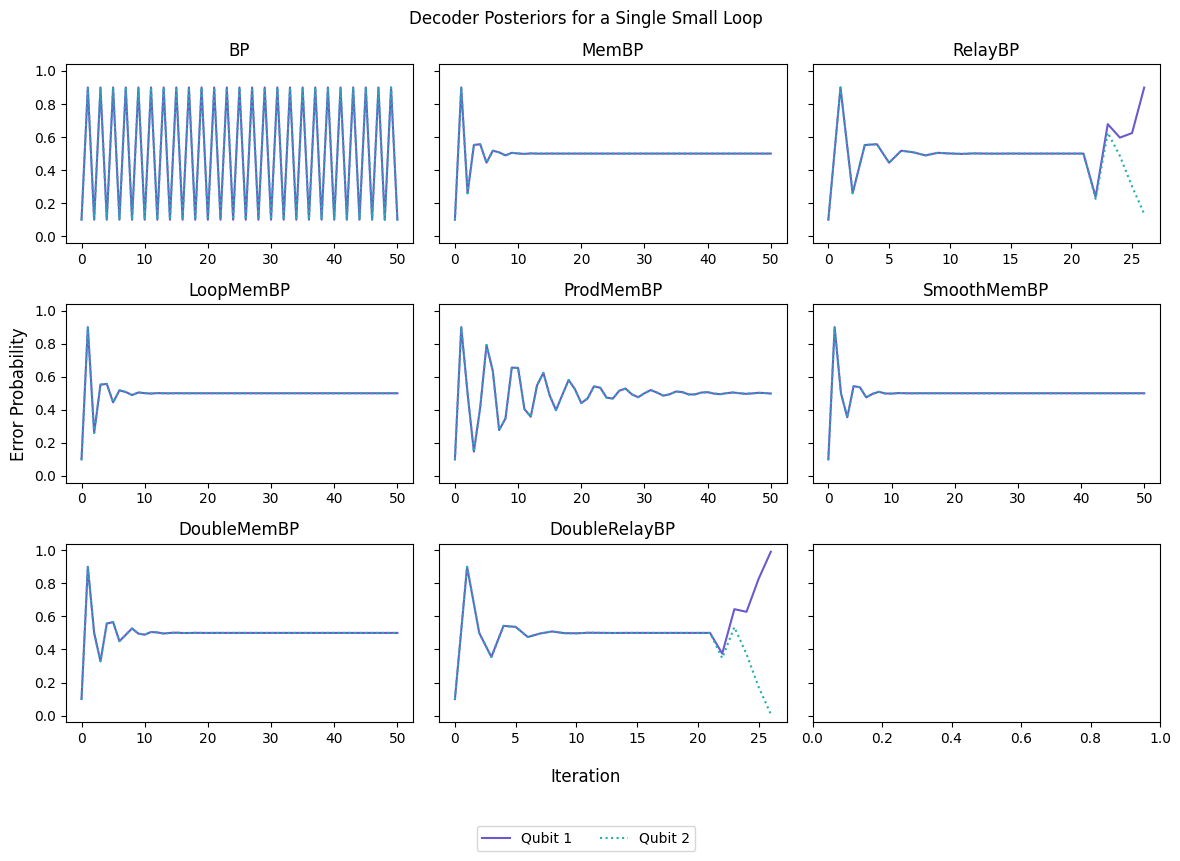

In [ ]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Small Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()


## Single Medium Loop

In [ ]:
field = Field(2)
h = (np.array([[-1, 1, 0, 0],
              [0, -1, -1, 0],
              [0, 0, 1, -1],
              [1, 0, 0, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
# priors = np.array([[0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05],
#                    [0.9, 0.05, 0.05]], dtype=float)
syndrome = (h @ np.array([0, 1, 1, 0])) % field.p
loopsize=2

c = 0.2
w = 0.5

bp = BP(field, h, priors, 50)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)), 2*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)


In [ ]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True


/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:516: RuntimeWarning: invalid value encountered in divide
  sub_posteriors / np.sum(sub_posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:537: RuntimeWarning: invalid value encountered in divide
  posteriors /= np.sum(posteriors, axis=1)[:, np.newaxis]
/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:219: RuntimeWarning: invalid value encountered in divide
  sub_convolutions = sub_convolutions / convolution


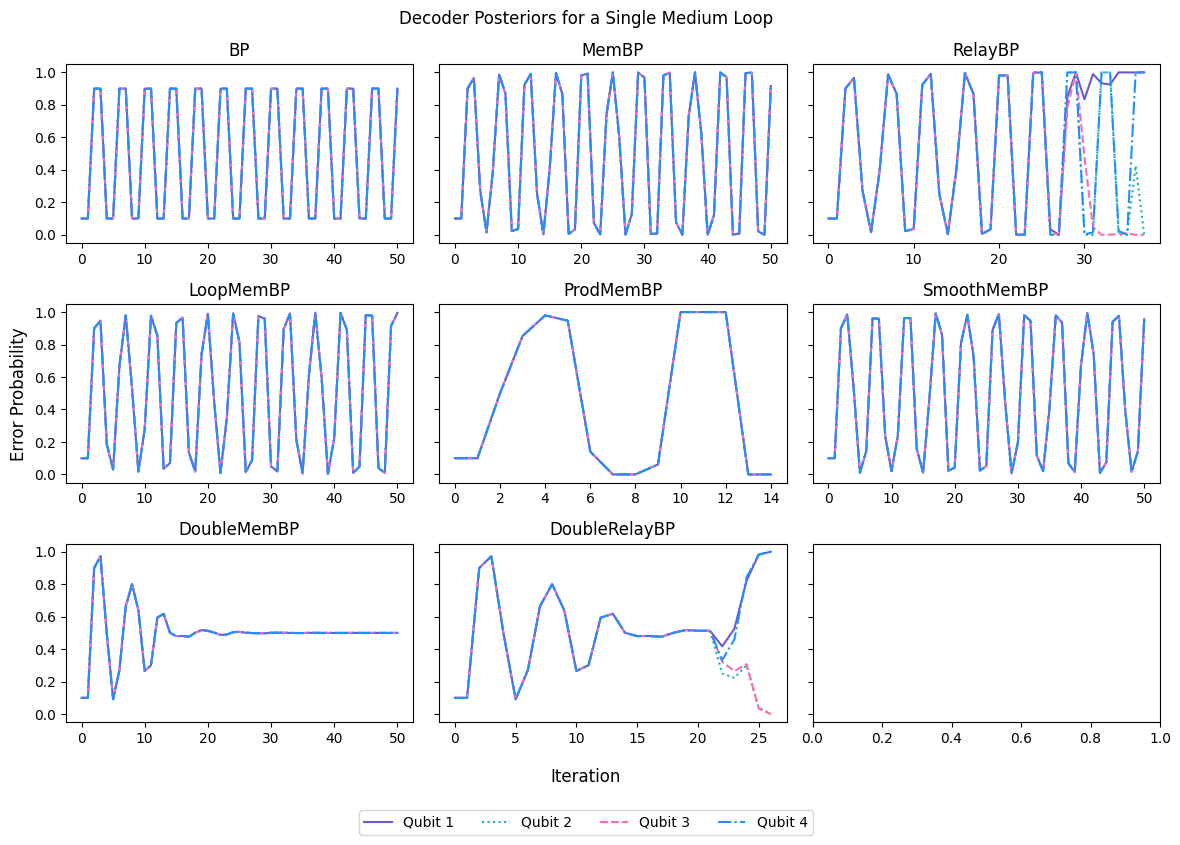

In [ ]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':', '--', '-.']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Medium Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()


## Single Large Loop

In [ ]:
field = Field(2)
h = (np.array([[1, 1, 0, 0, 0, 0],
              [0, 1, 1, 0, 0, 0],
              [0, 0, 1, 1, 0, 0],
              [0, 0, 0, 1, 1, 0],
              [0, 0, 0, 0, 1, 1],
              [1, 0, 0, 0, 0, 1]])) % field.p
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
syndrome = (h @ np.array([0, 1, 1, 1, 0, 0])) % field.p
loopsize=3

c = 0.2
w = 0.5

bp = BP(field, h, priors, 50)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), 1.5*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)


In [ ]:
rustrelaybp = RelayDecoderF32(h, error_priors=priors[:, 1], gamma0=c, pre_iter=20, num_sets=3, set_max_iter=10, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
x_syndrome_history = syndrome.astype(np.uint8)
guessed_error = rustrelaybp.decode(x_syndrome_history)


In [ ]:
guessed_error


array([0, 1, 1, 1, 0, 0], dtype=uint8)

In [ ]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: False
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True


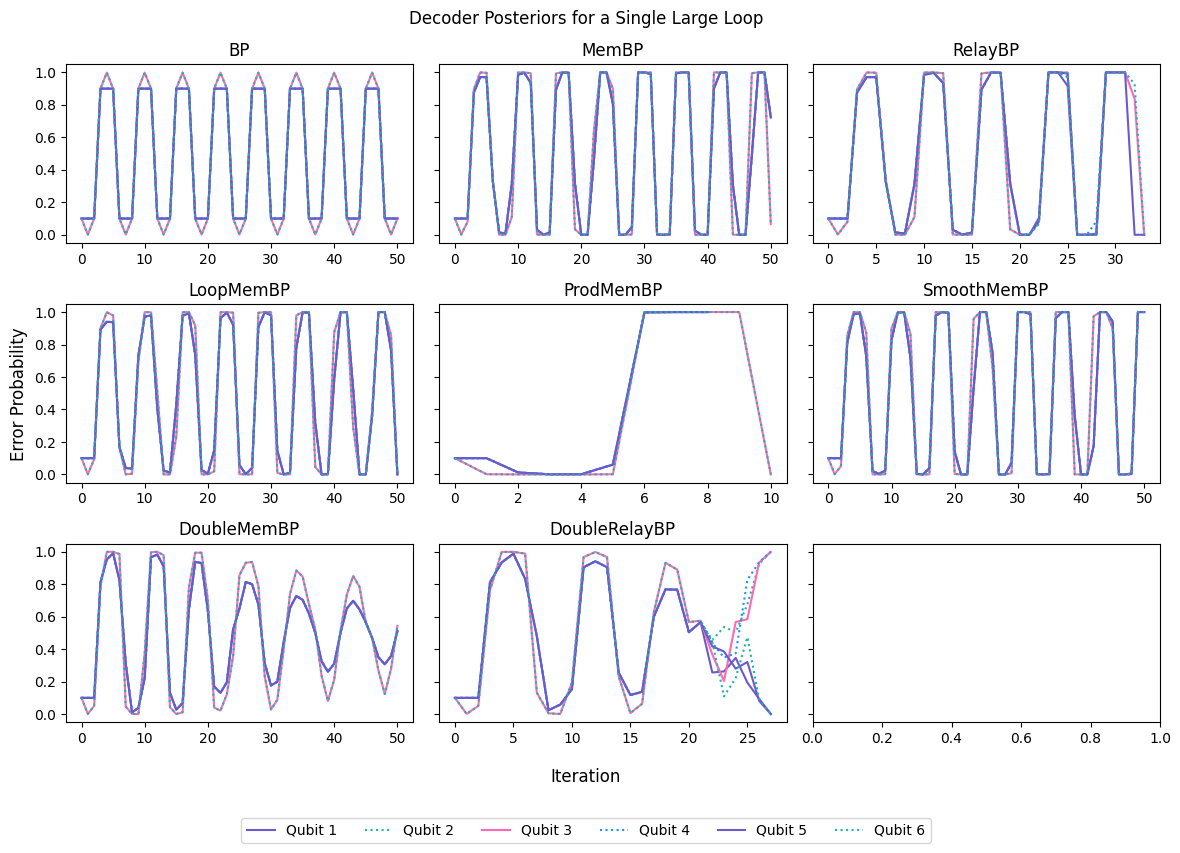

In [ ]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen"]
linestyles = ['-', ':', '-', ':', '-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Single Large Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.07))
fig.tight_layout()


## Almost Surface Code 9-Loop

In [ ]:
field = Field(2)
h = np.array([[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
              [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]
              ])
priors = np.array([[0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1],
                   [0.9, 0.1]], dtype=float)
syndrome = np.array([1, 0, 0, 0, 0, 0, 0, 0, 1])
loopsize=3

c = 0.2
w = 0.5

bp = BP(field, h, priors, 50)
membp = RelayBP(field, h, priors, 50, 50, 1, 1, 0.2*np.ones((h.shape[1], field.p, 1)))

mem_weight = np.zeros((h.shape[1], field.p, 4))
mem_weight[:, :, 0] = c
mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(h.shape[1], field.p, 4 - 1))
relaybp = RelayBP(field, h, priors, 10, 20, 3, 4, mem_weight)

loopmembp = RelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)) / loopsize)
prodmembp = ProdRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)))
smoothmembp = SmoothRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), loopsize)
doublemembp = DoubleRelayBP(field, h, priors, 50, 50, 1, 1, c*np.ones((h.shape[1], field.p, 1)), 1.3*np.ones((h.shape[1], field.p, 1)), loopsize)
doublerelaybp = DoubleRelayBP(field, h, priors, 10, 20, 3, 4, mem_weight, 2*np.ones((h.shape[1], field.p, 4)), loopsize)


In [ ]:
error, success, _, final_post, posteriors_bp = bp.decode(syndrome, debug=True, metric=True)
posteriors_bp = np.array(posteriors_bp)
print(f"BP succeeded: {success}")

error, success, _, posteriors_mem = membp.decode(syndrome, debug=True, metric=True)
posteriors_mem = np.array(posteriors_mem)
print(f"MemBP succeeded: {success}")

error, success, _, posteriors_relay = relaybp.decode(syndrome, debug=True, metric=True)
posteriors_relay = np.array(posteriors_relay)
print(f"RelayBP succeeded: {success}")

error, success, _, posteriors_loopmem = loopmembp.decode(syndrome, debug=True, metric=True)
posteriors_loopmem = np.array(posteriors_loopmem)
print(f"LoopMemBP succeeded: {success}")

error, success, _, posteriors_prodmem = prodmembp.decode(syndrome, debug=True, metric=True)
posteriors_prodmem = np.array(posteriors_prodmem)
print(f"ProdMemBP succeeded: {success}")

error, success, _, posteriors_smoothmem = smoothmembp.decode(syndrome, debug=True, metric=True)
posteriors_smoothmem = np.array(posteriors_smoothmem)
print(f"SmoothMemBP succeeded: {success}")

error, success, _, posteriors_doublemem = doublemembp.decode(syndrome, debug=True, metric=True)
posteriors_doublemem = np.array(posteriors_doublemem)
print(f"DoubleMemBP succeeded: {success}")

error, success, _, posteriors_doublerelay = doublerelaybp.decode(syndrome, debug=True, metric=True)
posteriors_doublerelay = np.array(posteriors_doublerelay)
print(f"DoubleRelayBP succeeded: {success}")


BP succeeded: False
MemBP succeeded: False
RelayBP succeeded: True
LoopMemBP succeeded: False
ProdMemBP succeeded: False
SmoothMemBP succeeded: False
DoubleMemBP succeeded: False
DoubleRelayBP succeeded: True


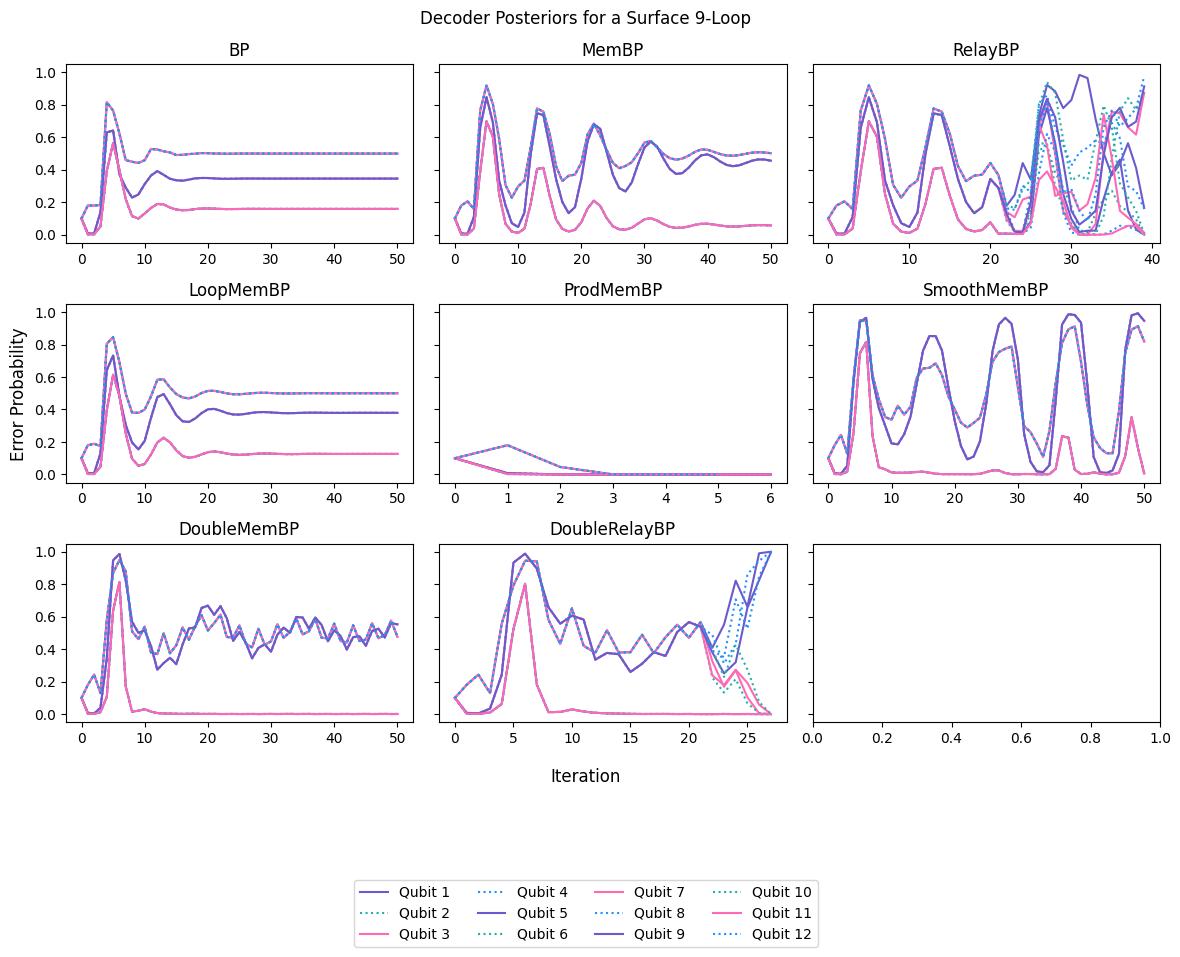

In [15]:
colours = ["slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen", "hotpink", "dodgerblue", "slateblue", "lightseagreen", "hotpink", "dodgerblue"]
linestyles = ['-', ':', '-', ':', '-', ':', '-', ':', '-', ':', '-', ':']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8), sharey=True)
fig.suptitle('Decoder Posteriors for a Surface 9-Loop')
fig.supxlabel('Iteration')
fig.supylabel('Error Probability')

axs[0, 0].set_title('BP')
axs[0, 1].set_title('MemBP')
axs[0, 2].set_title('RelayBP')
axs[1, 0].set_title('LoopMemBP')
axs[1, 1].set_title('ProdMemBP')
axs[1, 2].set_title('SmoothMemBP')
axs[2, 0].set_title('DoubleMemBP')
axs[2, 1].set_title('DoubleRelayBP')

for qubit in range(posteriors_bp.shape[1]):
    axs[0, 0].plot(posteriors_bp[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit], label = f"Qubit {qubit+1}")
    axs[0, 1].plot(posteriors_mem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[0, 2].plot(posteriors_relay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 0].plot(posteriors_loopmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 1].plot(posteriors_prodmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[1, 2].plot(posteriors_smoothmem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 0].plot(posteriors_doublemem[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])
    axs[2, 1].plot(posteriors_doublerelay[:, qubit, 1], color=colours[qubit], linestyle=linestyles[qubit])

fig.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()


## Simulation

In [9]:
d = 5
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

p = 0.03
num_trials = 3000

bp_max_iter = 300

max_iter = 60
first_iter = 80
solutions = 1
relays = 10

c = 0.05
w = 0.2

loopsize = 1


In [10]:
physical_error = np.logspace(-0.7, -1.8, 10)
num_failures = [10 for _ in range(10)]
physical_error


array([0.19952623, 0.15058364, 0.11364637, 0.08576959, 0.06473082,
       0.04885274, 0.03686945, 0.02782559, 0.02100014, 0.01584893])

In [11]:
def decode(failures, ind, results, trials, decoder, syndrome, error, field, lx, num_failures, s):
    if failures < num_failures[ind]:
        guessed_error, decoder_success, bp_success, posterior = decoder.decode(syndrome, debug=True, metric=False)
        error_difference = (error - guessed_error) % field.p
        logical_effect = (np.array(lx) @ error_difference) % field.p

        if np.any(logical_effect != 0):
            failures += 1

        if failures == num_failures[ind]:
            results.append(trials)
            print(f'Completed {s}: {trials}')
    return failures, results


In [12]:
print(f'Simulation for error rates {physical_error}')

results_rust = []
results_relaybp = []
results_bposd = []
results_bp = []
results_membp = []
results_smoothrelay = []
results_doublerelay = []

for ind, p in enumerate(physical_error):
    print(f'Starting trials for p={p:.2f}')

    n_qudits = hx.shape[1]
    channel_prob_x = np.ones(n_qudits) * p
    x_prior = np.zeros((n_qudits, field.p), dtype=float)

    for i, prob in enumerate(channel_prob_x):
        x_prior[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior[i, j] = prob / (field.p - 1)

    failures_rust = 0
    failures_relaybp = 0
    failures_bposd = 0
    failures_bp = 0
    failures_membp = 0
    failures_smoothrelay = 0
    failures_doublerelay = 0
    failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp, failures_membp, failures_smoothrelay, failures_doublerelay])

    trials = 0

    while failures < 7 * num_failures[ind]:
        trials += 1

        mem_weight = np.zeros((n_qudits, field.p, relays))
        mem_weight[:, :, 0] = c
        mem_weight[:, :, 1:] = np.random.uniform(c - w/2, c + w/2, size=(n_qudits, field.p, relays - 1))

        # Generate syndrome
        error = np.zeros(n_qudits, dtype=int)
        error_mask = np.random.rand(n_qudits) < p
        for i in np.where(error_mask)[0]:
            error[i] = np.random.randint(1, field.p)
        syndrome = (hx @ error) % field.p

        # Decode
        failures_relaybp, results_relaybp = decode(failures_relaybp, ind, results_relaybp, trials, RelayBP(field, hx, x_prior, max_iter=max_iter, first_iter=first_iter, solutions=solutions, relays=relays, mem_weight=mem_weight), syndrome, error, field, lx, num_failures, 'RelayBP')
        failures_bposd, results_bposd = decode(failures_bposd, ind, results_bposd, trials, BPOSD(field, hx, x_prior, bp_max_iter), syndrome, error, field, lx, num_failures, 'BPOSD')
        failures_bp, results_bp = decode(failures_bp, ind, results_bp, trials, BP(field, hx, x_prior, bp_max_iter), syndrome, error, field, lx, num_failures, 'BP')
        failures_membp, results_membp = decode(failures_membp, ind, results_membp, trials, RelayBP(field, hx, x_prior, 50, 50, 1, 1, 0.2*np.ones((hx.shape[1], field.p, 1))), syndrome, error, field, lx, num_failures, 'MemBP')
        failures_smoothrelay, results_smoothrelay = decode(failures_smoothrelay, ind, results_smoothrelay, trials, SmoothRelayBP(field, hx, x_prior, 10, 20, 3, 4, c*np.ones((hx.shape[1], field.p, 4)), loopsize), syndrome, error, field, lx, num_failures, 'SmoothRelay')
        failures_doublerelay, results_doublerelay = decode(failures_doublerelay, ind, results_doublerelay, trials, DoubleRelayBP(field, hx, x_prior, 10, 20, 3, 4, mem_weight, 2*np.ones((hx.shape[1], field.p, 4)), loopsize), syndrome, error, field, lx, num_failures, 'DoubleRelay')

        if failures_rust < num_failures[ind]:
            rustrelaybp = RelayDecoderF32(hx, error_priors=channel_prob_x, gamma0=c, pre_iter=20, num_sets=4, set_max_iter=10, gamma_dist_interval=(c - w/2, c + w/2), stop_nconv=1)
            syndrome = syndrome.astype(np.uint8)
            guessed_error = rustrelaybp.decode(syndrome)
            error_difference = (error - guessed_error) % field.p
            logical_effect = (np.array(lx) @ error_difference) % field.p

            if np.any(logical_effect != 0):
                failures_rust += 1

            if failures_rust == num_failures[ind]:
                results_rust.append(trials)
                print(f'Completed RustRelayBP: {trials}')

            if trials % 100 == 0:
                print(f'UPDATE: {trials} trials reached.')

        failures = sum([failures_rust, failures_relaybp, failures_bposd, failures_bp, failures_membp, failures_smoothrelay, failures_doublerelay])
    print(f'[{ind+1}/{len(physical_error)}]')


Simulation for error rates [0.19952623 0.15058364 0.11364637 0.08576959 0.06473082 0.04885274
 0.03686945 0.02782559 0.02100014 0.01584893]
Starting trials for p=0.20
Completed RelayBP: 12
Completed BPOSD: 12
Completed BP: 12
Completed RustRelayBP: 12
Completed SmoothRelay: 14
Completed DoubleRelay: 14
Completed MemBP: 17
[1/10]
Starting trials for p=0.15
Completed BPOSD: 15
Completed SmoothRelay: 15
Completed DoubleRelay: 15
Completed MemBP: 16
Completed RustRelayBP: 17
Completed RelayBP: 19
Completed BP: 19
[2/10]
Starting trials for p=0.11
Completed BP: 34
Completed DoubleRelay: 35
Completed RelayBP: 38
Completed BPOSD: 38
Completed SmoothRelay: 38
Completed MemBP: 39
Completed RustRelayBP: 39
[3/10]
Starting trials for p=0.09
Completed BP: 31
Completed RustRelayBP: 38
Completed SmoothRelay: 40
Completed DoubleRelay: 45
Completed MemBP: 75
Completed RelayBP: 77
Completed BPOSD: 83
[4/10]
Starting trials for p=0.06
Completed BP: 83
UPDATE: 100 trials reached.
Completed SmoothRelay: 1

/Users/eleanorkneip/Documents/phd/bbq-project/bbqudit/bbq/decoder.py:516: RuntimeWarning: invalid value encountered in divide
  sub_posteriors / np.sum(sub_posteriors, axis=1)[:, np.newaxis]


UPDATE: 100 trials reached.
Completed BP: 129
Completed RustRelayBP: 147
Completed MemBP: 177
Completed SmoothRelay: 177
Completed DoubleRelay: 201
Completed RelayBP: 208
Completed BPOSD: 229
[6/10]
Starting trials for p=0.04
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
Completed BP: 249
UPDATE: 300 trials reached.
Completed SmoothRelay: 341
Completed RustRelayBP: 394
Completed MemBP: 400
Completed DoubleRelay: 400
Completed BPOSD: 727
Completed RelayBP: 753
[7/10]
Starting trials for p=0.03
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
Completed BP: 265
UPDATE: 300 trials reached.
Completed SmoothRelay: 343
UPDATE: 400 trials reached.
Completed DoubleRelay: 424
UPDATE: 500 trials reached.
Completed RustRelayBP: 550
Completed MemBP: 691
Completed RelayBP: 2567
Completed BPOSD: 2567
[8/10]
Starting trials for p=0.02
UPDATE: 100 trials reached.
UPDATE: 200 trials reached.
UPDATE: 300 trials reached.
Completed BP: 395
UPDATE: 400 trials reached.
UPDATE: 500 trials rea

In [14]:
results_5 = {'rust' : results_rust, 'relaybp' : results_relaybp, 'bposd' : results_bposd, 'bp' : results_bp, 'membp' : results_membp, 'smooth' : results_smoothrelay, 'double' : results_doublerelay}
print(results_5.__repr__())


{'rust': [12, 17, 39, 38, 117, 147, 394, 550, 1916, 7445], 'relaybp': [12, 19, 38, 77, 143, 208, 753, 2567, 5800, 12622], 'bposd': [12, 15, 38, 83, 160, 229, 727, 2567, 3997, 12622], 'bp': [12, 19, 34, 31, 83, 129, 249, 265, 395, 1038], 'membp': [17, 16, 39, 75, 143, 177, 400, 691, 1082, 2492], 'smooth': [14, 15, 38, 40, 117, 177, 341, 343, 903, 2384], 'double': [14, 15, 35, 45, 120, 201, 400, 424, 1133, 3442]}


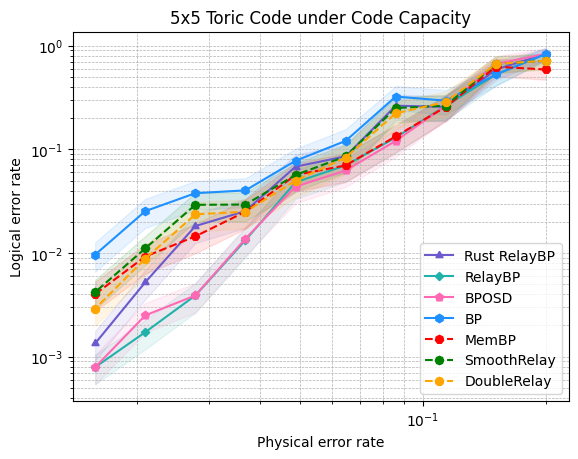

In [18]:
results_5 = {'rust': [12, 17, 39, 38, 117, 147, 394, 550, 1916, 7445], 'relaybp': [12, 19, 38, 77, 143, 208, 753, 2567, 5800, 12622], 'bposd': [12, 15, 38, 83, 160, 229, 727, 2567, 3997, 12622], 'bp': [12, 19, 34, 31, 83, 129, 249, 265, 395, 1038], 'membp': [17, 16, 39, 75, 143, 177, 400, 691, 1082, 2492], 'smooth': [14, 15, 38, 40, 117, 177, 341, 343, 903, 2384], 'double': [14, 15, 35, 45, 120, 201, 400, 424, 1133, 3442]}

legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='--', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='--', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='--', label='DoubleRelay')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_5, {'rust':10, 'relaybp':10, 'bposd':10, 'bp':10, 'membp':10, 'smooth':10, 'double':10}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('5x5 Toric Code under Code Capacity');


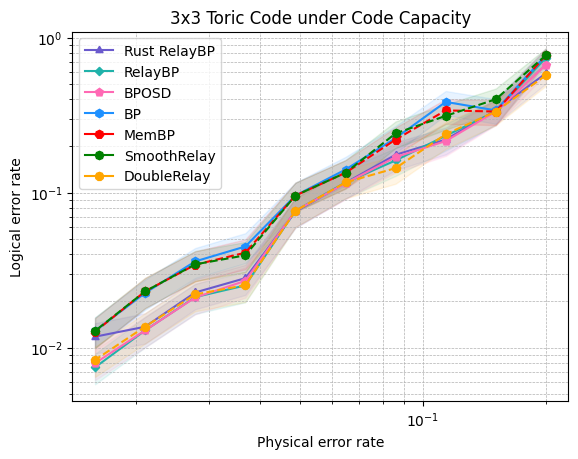

In [8]:
results_3 = {'rust': [34, 59, 91, 114, 173, 265, 712, 880, 1464, 1697], 
 'relaybp': [27, 60, 86, 124, 172, 262, 793, 943, 1546, 2675], 
 'bposd': [30, 60, 93, 118, 174, 262, 741, 948, 1546, 2515], 
 'bp': [26, 59, 52, 89, 142, 209, 445, 555, 887, 1559], 
 'membp': [26, 60, 59, 91, 149, 209, 488, 583, 866, 1576], 
 'smooth': [26, 50, 64, 83, 149, 209, 507, 580, 866, 1559], 
 'double': [35, 60, 84, 139, 172, 262, 790, 906, 1461, 2399]}

legend_elements = [
    Line2D([0], [0], color='slateblue', marker=(3, 0, 0), linestyle='-', label='Rust RelayBP'),
    Line2D([0], [0], color='lightseagreen', marker=(4, 0, 0), linestyle='-', label='RelayBP'),
    Line2D([0], [0], color='hotpink', marker=(5, 0, 0), linestyle='-', label='BPOSD'),
    Line2D([0], [0], color='dodgerblue', marker=(6, 0, 0), linestyle='-', label='BP'),
    Line2D([0], [0], color='red', marker=(7, 0, 0), linestyle='-', label='MemBP'),
    Line2D([0], [0], color='green', marker=(8, 0, 0), linestyle='-', label='SmoothRelay'),
    Line2D([0], [0], color='orange', marker=(9, 0, 0), linestyle='-', label='DoubleRelay')
]

physical_error = np.logspace(-0.7, -1.8, 10)
plot_results, plot_errors = process_results(results_3, {'rust':20, 'relaybp':20, 'bposd':20, 'bp':20, 'membp':20, 'smooth':20, 'double':20}, "code_capacity")
alpha = 0.1

fig, ax = plt.subplots()

ax.loglog(physical_error, plot_results['rust'], color='slateblue', marker=(3, 0, 0))
ax.loglog(physical_error, plot_results['relaybp'], color='lightseagreen', marker=(4, 0, 0))
ax.loglog(physical_error, plot_results['bposd'], color='hotpink', marker=(5, 0, 0))
ax.loglog(physical_error, plot_results['bp'], color='dodgerblue', marker=(6, 0, 0))
ax.loglog(physical_error, plot_results['membp'], color='red', marker=(7, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['smooth'], color='green', marker=(8, 0, 0), linestyle="--")
ax.loglog(physical_error, plot_results['double'], color='orange', marker=(9, 0, 0), linestyle="--")
ax.fill_between(physical_error, plot_results['rust'] - plot_errors['rust'], plot_results['rust'] + plot_errors['rust'], color='slateblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['relaybp'] - plot_errors['relaybp'], plot_results['relaybp'] + plot_errors['relaybp'], color='lightseagreen', alpha=alpha)
ax.fill_between(physical_error, plot_results['bposd'] - plot_errors['bposd'], plot_results['bposd'] + plot_errors['bposd'], color='hotpink', alpha=alpha)
ax.fill_between(physical_error, plot_results['bp'] - plot_errors['bp'], plot_results['bp'] + plot_errors['bp'], color='dodgerblue', alpha=alpha)
ax.fill_between(physical_error, plot_results['membp'] - plot_errors['membp'], plot_results['membp'] + plot_errors['membp'], color='red', alpha=alpha)
ax.fill_between(physical_error, plot_results['smooth'] - plot_errors['smooth'], plot_results['smooth'] + plot_errors['smooth'], color='green', alpha=alpha)
ax.fill_between(physical_error, plot_results['double'] - plot_errors['double'], plot_results['double'] + plot_errors['double'], color='orange', alpha=alpha)

ax.set_xlabel('Physical error rate')
ax.set_ylabel('Logical error rate')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(handles=legend_elements)
ax.set_title('3x3 Toric Code under Code Capacity');
